In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# IRIS 데이터셋 가지고 KNN 이진분류를 연습해보자

iris 데이터셋 중, versicolor를 삭제하고 나머지 두종류로 이진분류를 함

## 1. 데이터 읽어오기

In [6]:
iris = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/iris.csv')
iris.head()

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


versicolor 버리기

In [9]:
iris = iris.loc[ (iris['Species'] == 'setosa') | (iris['Species'] == 'virginica'), : ]

### EDA (이상치 결측치 확인)

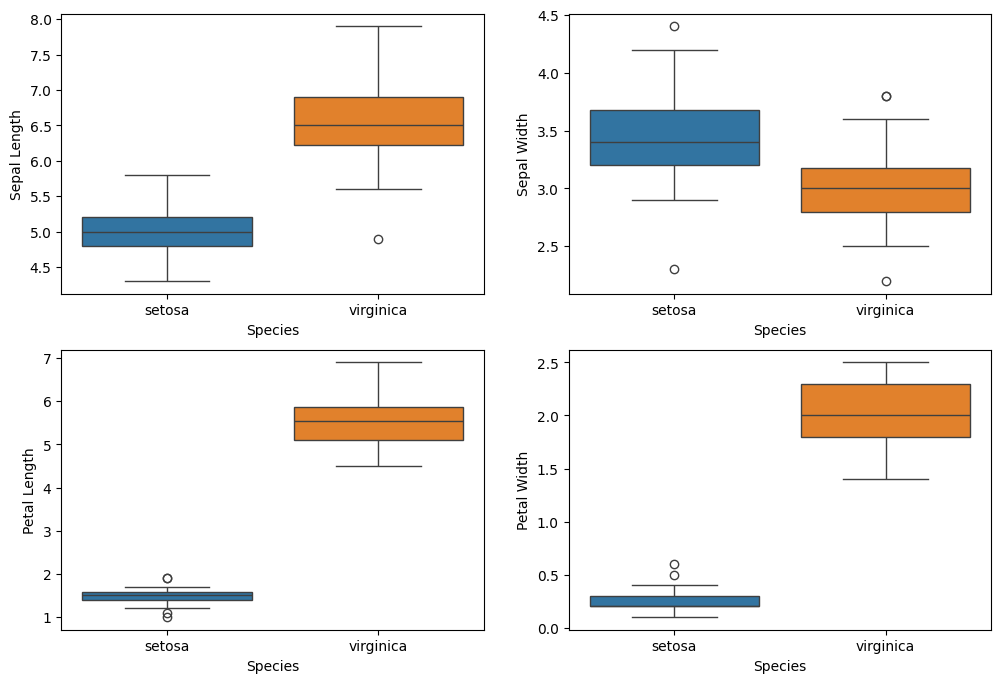

In [11]:
numeric_cols = iris[['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.reshape(-1)
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="Species", y=col, data=iris, hue="Species", ax=axes[i])
plt.show()

In [12]:
outliers = {}
for col in numeric_cols:
  Q1 = iris[col].quantile(0.25)    # 25%
  Q3 = iris[col].quantile(0.75)    # 75%

  IQR = Q3 - Q1   # 박스의 높이

  lower_bound = Q1 - IQR*1.5
  upper_bound = Q3 + IQR*1.5

  outlier = iris.loc[ (iris[col] < lower_bound) | (iris[col] > upper_bound), : ]

  outliers[col] = outlier

In [13]:
# 결측치 확인
iris.isna().sum()

,0
Sepal Length,0
Sepal Width,0
Petal Length,0
Petal Width,0
Species,0


## Train, Validation, Test 데이터셋 분리

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
train, test = train_test_split(iris, test_size=0.2, random_state=SEED)    # train 8, test 2
# 종속변수x와 독립변수y로 나누기
x_train = train.drop('Species', axis=1)
y_train = train['Species']
x_train, x_validation, y_train, y_validation = train_test_split(
          x_train, y_train, test_size=0.25, random_state=SEED
          )     # train 6, validation 2

## 데이터 전처리

### Encoding

In [16]:
label_dict = {'setosa' : 0, 'virginica' : 1}
y_train_e = y_train.map(label_dict)
y_validation_e = y_validation.map(label_dict)

### Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

scaler.fit(x_train)
scaler.fit(x_validation)
x_train_standard_s = scaler.transform(x_train)
x_validation_standard_s = scaler.transform(x_validation)

y_train = y_train_e.to_numpy()
y_validation = y_validation_e.to_numpy()

## 모델 학습

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(x_train_standard_s, y_train_e)

KNeighborsClassifier()

##학습 결과 확인

In [22]:
y_predict = clf.predict(x_validation_standard_s)
print(y_predict[:20])   # 학습된 기계가 예측한 값
print(y_validation[:20])    # 실제 정답

print ((y_validation == y_predict).sum() / len(y_validation)  )   # 정확도

[0 1 0 0 0 1 0 1 1 1 1 0 0 1 0 1 1 1 1 1]
[0 1 0 0 0 1 0 1 1 1 1 0 0 1 0 1 1 1 1 1]
1.0


### Confusion Matrix

In [23]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

1. Accuracy: 1.0000
2. Recall: 1.0000
3. Precision: 1.0000
4. F1 Score: 1.0000


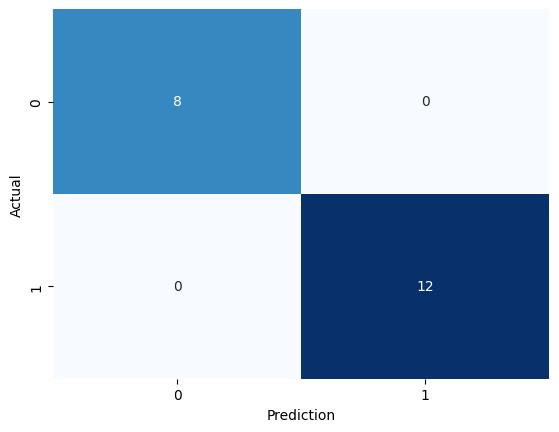

In [24]:
print_metrics(y_validation, y_predict)

## Cross Validation

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
clf = KNeighborsClassifier()
param_grid = {'n_neighbors' : [3,5,7,9,11],
              'weights' : ['uniform', 'distance'],
              'p' : [1,2]
              }

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_standard_s, y_train_e)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9, 11], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')